# Redshift fitting from strong emission lines

`jwspecfit.fit_redshift` determines the redshift of a JWST NIRSpec spectrum by jointly fitting the amplitudes of a curated strong-line set, plus a low-order polynomial continuum, on a dense grid of trial redshifts spanning `z = 0 → 20`.

Key properties:

- **Exhaustive**: the full coarse grid is always evaluated. There is no early stopping.
- **Coverage-aware**: lines whose expected observed wavelength falls outside the spectrum at the trial redshift are silently dropped. The same call works for `z = 0.5` and for `z = 12`.
- **Non-Gaussian priors**: `None` (flat), `(lo, hi)` window, list of disjoint windows, or any callable `p(z)`.
- **Confidence**: returns both a per-peak 68/95 % credible interval *and* a ranked list of secondary peaks with their Δχ² — so a tight statistical CI on the wrong peak cannot hide.

This notebook demonstrates the API on a real JWST/NIRSpec G395M spectrum of a `z ≈ 6.105` galaxy from the Stark sample (RXC J2248).

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import jwspecfit

## 1. Load the spectrum

We load the file *without* setting `z`, because the whole point is that the fitter will find it. The known literature value (`z = 6.1052`) is only used at the end to check the recovery.

In [2]:
SPEC_PATH = "../../data/stark-rxcj2248-v4_g395m-f290lp_2478_3.spec.fits"
Z_LITERATURE = 6.1052

spec = jwspecfit.read_fits(SPEC_PATH)
print(f"grating          = {spec.grating}")
print(f"wavelength range = {spec.wave_um.min():.2f} – {spec.wave_um.max():.2f} µm")
print(f"valid pixels     = {spec.mask_valid().sum()} / {spec.n_pix}")

grating          = G395M
wavelength range = 2.68 – 5.51 µm
valid pixels     = 1484 / 1661


## 2. Run the fitter with defaults

Default settings:

- Search `z \in [0, 20]` with a coarse-grid step tied to the spectrum's resolving power (floored at `10^{-3}`).
- Fit the curated `DEFAULT_LINES` set (UV through optical strong lines).
- Flat prior.
- Non-negative line amplitudes (emission only).
- Refine all coarse-grid local minima within `Δχ² = 9` of the best, plus at least the top 5 peaks overall.

The full sweep below evaluates roughly 20 000 trial redshifts in under 10 seconds.

In [3]:
%%time
result = jwspecfit.fit_redshift(spec)
print(result)

RedshiftResult(z_best=6.10360, ci68=(6.103562104668746, 6.10363452993718), decisive=True, n_peaks=5)
CPU times: user 2.04 s, sys: 4.16 s, total: 6.2 s
Wall time: 1.49 s


## 3. Inspect the result

The `RedshiftResult` object carries the best-fit redshift, its 68/95 % credible interval, every secondary peak that survived refinement, and the full coarse + refined χ² curves and `P(z)` arrays.

In [4]:
print(f"z_best      = {result.z_best:.5f}")
print(f"vs truth    = {Z_LITERATURE} (diff = {result.z_best - Z_LITERATURE:+.5f})")
print(f"CI68        = ({result.z_ci68[0]:.5f}, {result.z_ci68[1]:.5f})")
print(f"CI95        = ({result.z_ci95[0]:.5f}, {result.z_ci95[1]:.5f})")
print(f"is_decisive = {result.is_decisive}  (Δχ² to runner-up = {result.peaks[1].dchi2:.1f})")
print()
print("Top peaks:")
for i, p in enumerate(result.peaks[:5]):
    print(f"  {i + 1}. z = {p.z:.5f}  prob = {p.prob:.3e}  Δχ² = {p.dchi2:8.1f}  n_lines = {p.n_lines_used}")
print()
print(f"Best-peak lines drove the fit: {result.peaks[0].lines_used}")

z_best      = 6.10360
vs truth    = 6.1052 (diff = -0.00160)
CI68        = (6.10356, 6.10363)
CI95        = (6.10353, 6.10365)
is_decisive = True  (Δχ² to runner-up = 9643.3)

Top peaks:
  1. z = 6.10360  prob = 1.000e+00  Δχ² =      0.0  n_lines = 5
  2. z = 8.19585  prob = 0.000e+00  Δχ² =   9643.3  n_lines = 3
  3. z = 6.17230  prob = 0.000e+00  Δχ² =   9640.7  n_lines = 3
  4. z = 8.54454  prob = 0.000e+00  Δχ² =   9638.6  n_lines = 4
  5. z = 4.41949  prob = 0.000e+00  Δχ² =   9644.2  n_lines = 2

Best-peak lines drove the fit: ['NeIII_3869', 'HBETA', 'OIII_4959', 'OIII_5007', 'Ha']


Two distinct kinds of confidence are returned:

1. **Per-peak CI** (`z_ci68`, `z_ci95`): how tightly the data constrain `z` *within* the chosen peak, from integrating `exp(-Δχ²/2) · prior(z)` over the local mode.
2. **Peak-vs-peak** (`peaks`, `is_decisive`): how the best peak compares to the next-best alternative. `is_decisive` is `True` when the runner-up is more than 25 χ² units worse — the conventional spectroscopic-redshift threshold.

Here we are decisively at `z \approx 6.1036` (Δχ² to runner-up is in the thousands), with a per-peak CI of ± a few times `10^{-5}`. The small offset from the literature 6.1052 (≈10⁻³) is the usual systematic floor of strong-line z-fitting at `R = 1000`: pixel-centre evaluation of the Gaussian, finite LSF approximation, and possible vacuum-air convention differences.

## 4. Visualise the χ²(z) landscape

`RedshiftResult.plot()` gives a built-in two-panel plotly figure. For a static, paper-ready view, here is the matplotlib equivalent.

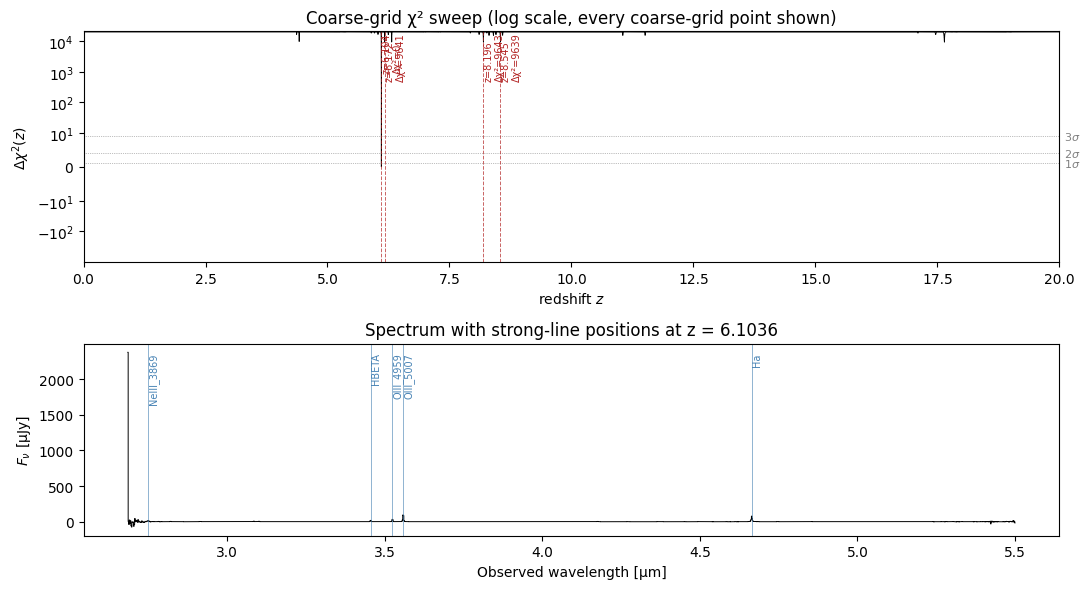

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), gridspec_kw={"height_ratios": [1.2, 1]})

dchi2 = result.chi2_coarse - np.nanmin(result.chi2_coarse)
ax1.plot(result.z_grid_coarse, dchi2, color="black", lw=0.6, drawstyle="steps-mid")
for thr, lab in ((1.0, r"$1\sigma$"), (4.0, r"$2\sigma$"), (9.0, r"$3\sigma$")):
    ax1.axhline(thr, color="grey", lw=0.5, ls=":")
    ax1.text(20.1, thr, lab, va="center", fontsize=8, color="grey")
for p in result.peaks[:4]:
    ax1.axvline(p.z, color="firebrick", ls="--", lw=0.7, alpha=0.7)
    ax1.text(p.z, ax1.get_ylim()[1] * 0.95,
             f"z={p.z:.3f}\nΔχ²={p.dchi2:.0f}",
             rotation=90, fontsize=7, va="top", color="firebrick")
ax1.set_yscale("symlog", linthresh=10)
ax1.set_xlim(0, 20)
ax1.set_ylabel(r"$\Delta\chi^2(z)$")
ax1.set_xlabel(r"redshift $z$")
ax1.set_title("Coarse-grid χ² sweep (log scale, every coarse-grid point shown)")

m = spec.mask_valid()
ax2.step(spec.wave_um[m], spec.flux_ujy[m], color="black", lw=0.7, where="mid")
for name in result.peaks[0].lines_used:
    lam_obs_um = jwspecfit.REST_LINES_A[name] * (1 + result.z_best) * 1e-4
    ax2.axvline(lam_obs_um, color="steelblue", lw=0.6, alpha=0.7)
    ax2.text(lam_obs_um, ax2.get_ylim()[1] * 0.95, name,
             rotation=90, fontsize=7, va="top", color="steelblue")
ax2.set_xlabel(r"Observed wavelength [µm]")
ax2.set_ylabel(r"$F_\nu$ [µJy]")
ax2.set_title(f"Spectrum with strong-line positions at z = {result.z_best:.4f}")
fig.tight_layout()
plt.show()

Note the **Δχ² axis is symlog**: outside the peak the chi-squared difference runs into the thousands. The peak at `z ≈ 6.10` is essentially the only place in the entire `0 → 20` interval where `Δχ²` drops back near zero — that is what "decisive" looks like.

## 5. Priors

The prior shape is fully under user control. It is never softened with a Gaussian by default — a flat prior gives every redshift equal opportunity to fit.

### 5.1 Single window

In [6]:
result_window = jwspecfit.fit_redshift(spec, prior=(5.0, 7.0))
print(f"flat-prior   z_best = {result.z_best:.5f}")
print(f"window prior z_best = {result_window.z_best:.5f}")

flat-prior   z_best = 6.10360
window prior z_best = 6.10360


### 5.2 Disjoint windows

Useful for e.g. testing whether a candidate at `z \approx 6` could also be explained by a much higher-z interpretation, while excluding implausible intermediate redshifts.

In [7]:
result_dual = jwspecfit.fit_redshift(spec, prior=[(5.0, 7.0), (10.0, 15.0)])
print(f"dual-window  z_best = {result_dual.z_best:.5f}")
print("Peaks in the dual-window run:")
for p in result_dual.peaks[:4]:
    print(f"  z = {p.z:.5f}  prob = {p.prob:.3e}  Δχ² = {p.dchi2:.1f}")

dual-window  z_best = 6.10360
Peaks in the dual-window run:
  z = 6.10360  prob = 1.000e+00  Δχ² = 0.0
  z = 6.17230  prob = 0.000e+00  Δχ² = 9640.7
  z = 11.05331  prob = 0.000e+00  Δχ² = 15837.5
  z = 5.89705  prob = 0.000e+00  Δχ² = 18733.2


### 5.3 Callable prior (e.g. a photo-z PDF)

Any function `p(z) \to \mathbb{R}_{\geq 0}` is accepted. Here we mock a photo-z prior peaked at `z = 6` with width 1.

In [8]:
def photoz_pdf(z):
    return np.exp(-0.5 * ((z - 6.0) / 1.0) ** 2)

result_phot = jwspecfit.fit_redshift(spec, prior=photoz_pdf)
print(f"callable-prior z_best = {result_phot.z_best:.5f}")

callable-prior z_best = 6.10360


### 5.4 What happens when the prior excludes the truth?

The fitter still returns its best peak — but inside the prior support. This is a deliberate property: the prior is a hard top-hat, and the algorithm will not silently "snap" to the global best if it lies outside the user's stated belief.

In [9]:
result_wrong = jwspecfit.fit_redshift(spec, prior=[(0.0, 5.0), (8.0, 15.0)])
print(f"prior-excludes-truth z_best = {result_wrong.z_best:.5f}")
print(f"  is_decisive = {result_wrong.is_decisive}")
print(f"  Top peaks:")
for p in result_wrong.peaks[:3]:
    print(f"    z = {p.z:.5f}  Δχ² = {p.dchi2:.1f}  n_lines = {p.n_lines_used}")

prior-excludes-truth z_best = 8.54454
  is_decisive = False
  Top peaks:
    z = 8.54454  Δχ² = 0.0  n_lines = 4
    z = 8.19585  Δχ² = 4.8  n_lines = 3
    z = 4.41949  Δχ² = 5.6  n_lines = 2


Notice that `Δχ²` to the *true* best is huge (the truth is gone from the search) but the algorithm cheerfully reports the best alias inside the prior. The `is_decisive` flag tells you whether to trust this constrained answer.

## 6. Restricting the line set

The default line set is robust at JWST PRISM and grating resolution, but you can pass any subset of `jwspecfit.REST_LINES_A`. This is useful when the source has known peculiarities (e.g. AGN broad lines, missing Lyman-α, very low-metallicity).

In [10]:
print(f"Default line set ({len(jwspecfit.DEFAULT_LINES)} lines):")
print("  " + ", ".join(jwspecfit.DEFAULT_LINES))

result_minimal = jwspecfit.fit_redshift(
    spec,
    lines=["HBETA", "OIII_4959", "OIII_5007", "Ha"],
)
print(f"\nFitting Hbeta + [OIII] doublet + Halpha only:")
print(f"  z_best = {result_minimal.z_best:.5f}")
print(f"  is_decisive = {result_minimal.is_decisive}")
print(f"  n_lines_used at best peak = {result_minimal.peaks[0].n_lines_used}")

Default line set (10 lines):
  Lya, CIV_doublet, HEII_1640, CIII], OII_doublet, NeIII_3869, HBETA, OIII_4959, OIII_5007, Ha



Fitting Hbeta + [OIII] doublet + Halpha only:
  z_best = 6.10360
  is_decisive = True
  n_lines_used at best peak = 4


## 7. Caveats and tips

- **Continuum**: the fitter adds a Legendre polynomial (`continuum_order=3` by default) to the per-z linear fit, so the spectrum's broadband shape is not absorbed by the lines. For very curved continua (e.g. heavily dust-attenuated UV slopes) try `continuum_order=5`.
- **Doublets**: most strong doublets are represented by a single "effective" line in `REST_LINES_A` (e.g. `"CIV_doublet"`, `"OII_doublet"`). At PRISM resolution this is correct; at medium-resolution gratings you can swap them out for the individual components (`"CIV_1"` + `"CIV_2"`) if line ratios matter to you.
- **`min_lines_in_range`**: a trial `z` that supports fewer than this many in-range lines is assigned the continuum-only χ² baseline, so it cannot generate a spurious peak. The default of 2 prevents single-line noise spikes from being promoted to candidate redshifts.
- **`is_decisive`**: do not blindly use the per-peak CI as an error bar without checking `is_decisive`. A tight CI on the wrong peak is still wrong.
- **Speed**: the full `z = 0 → 20` sweep takes a few seconds at PRISM and ~10 s at medium-resolution. For batch runs, the bottleneck is the inner least-squares step; nothing here parallelises across spectra, but Python-level `joblib.Parallel` over a list of spectra works fine.

## 8. After a successful redshift fit

Once `fit_redshift` has converged on a `z`, the natural next step is to call `jwspecfit.fit_lines` (or `fit_with_broad`) at that redshift to extract individual line fluxes and uncertainties for downstream science:

```python
z_use = result.z_best
line_fit = jwspecfit.fit_lines(spec, z=z_use)   # auto-selects lines for the grating

for name, line in line_fit.lines.items():
    if line.snr is not None and line.snr > 3:
        print(f"{name:14s}  flux = {line.flux:.3e} ± {line.flux_err:.2e}  S/N = {line.snr:.1f}")
```

See the [PRISM fit](01_prism_fit.ipynb) and [grating + broad](02_grating_broad.ipynb) notebooks for full follow-up examples.